# Face Detection with OpenCV & Haar Cascade
## Imports


In [1]:
import cv2
import os
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
# imdecode() / imread() / imwrite() / imshow()

2026-03-08 02:25:48.540192: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-08 02:25:48.549671: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 02:25:48.999403: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 02:25:50.861315: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Loading process
### Define paths

In [2]:
cascade_path = "../models/haarcascade-frontalface-default.xml"     # XML model file
image_path = "../data/samples/fear.jpg"      # Image to detect
model_path= "../models/my_model_emotion_detection_1.keras"

i=1
output_name="result_image"
output_path = f"../output/{output_name}.jpg"

# while not os.path.exists(output_name):
output_path = f"../output/{output_name}_{i}.jpg"
if not os.path.exists(model_path):
    print(f"Error: Model file not found at {model_path}")
    i+=1    

# --- Verify if files exist
if not os.path.exists(cascade_path):
    print(f"Error: Cascade file not found at {cascade_path}")
    exit()

if not os.path.exists(image_path):
    print(f"Error: Image not found at {image_path}")
    exit()

### Loading Classifier & Image

In [3]:
# EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
EMOTIONS=['angry', 'disgust','fear', 'happy','neutral', 'sad', 'surprise']
print("Loading Haar Cascade model...")
face_cascade = cv2.CascadeClassifier(cascade_path)      # Create detector & load XML

print("Loading Emotion Detection model...")
emotion_model = load_model(model_path)
    
print("Loading image...")
image = cv2.imread(image_path)

Loading Haar Cascade model...
Loading Emotion Detection model...


2026-03-08 02:25:51.673750: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loading image...


## Detection Process

Detecting Face...
Found: 1 face(s)!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


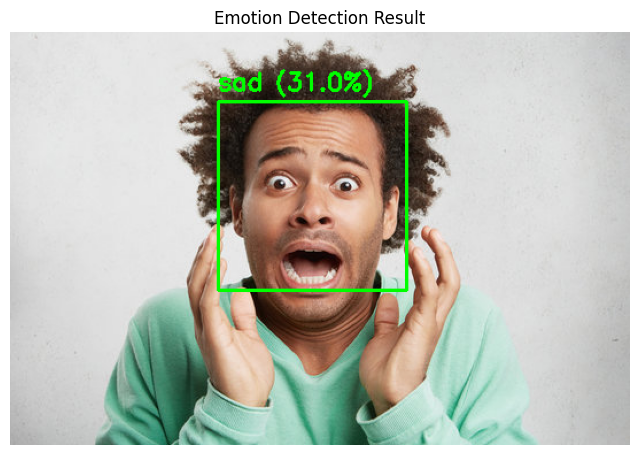

In [ ]:
# --- Preprocessing (Crucial) ---
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- Run Detection ---
print("Detecting Face...")

# Faces: a list of rectangles (x, y, Width, Height)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,  # How much to reduce the image at each "pass"
    minNeighbors=5,   # "neighbors" each rectangle must have to be valid
    minSize=(30, 30)  # Min size of a face to be detected
)

print(f"Found: {len(faces)} face(s)!")

# --- Drawing Rectangles ---
# Loop over each face/rectangle found 
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2) # 2 = Line thickness

    # 2. Extract the Region of Interest (ROI) - Just the face
    roi_gray = gray[y:y+h, x:x+w]
    
    # 3. Preprocess the ROI for the CNN
    roi_resized = cv2.resize(roi_gray, (48, 48))  # Resize to match training data
    
    # while training data is normalized : Rescaling(1./255)) 
    roi_resized = roi_resized / 255.0 
    roi_reshaped = np.reshape(roi_resized, (1, 48, 48, 1)) # Add batch & channel dimensions
    
    # 4. Predict the Emotion
    prediction = emotion_model.predict(roi_reshaped)
    max_index = np.argmax(prediction[0])
    predicted_emotion = EMOTIONS[max_index]
    confidence = prediction[0][max_index] * 100  # Convert probability to percentage
    
    # 5. Draw the Emotion & Confidence Score
    text = f"{predicted_emotion} ({confidence:.1f}%)"
    
    # Put text slightly above the rectangle
    cv2.putText(image, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)


# --- 6. Show the Image Inline ---
# OpenCV : BGR colors -> Matplotlib : RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Display the image 
plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.axis('off') # cleaner look : hides x & y
plt.title("Emotion Detection Result")
plt.show()

### Save the result

In [5]:
cv2.imwrite(output_path, image)
print(f"Image saved as: {output_path}")

Image saved as: ../output/result_image_1.jpg


### Silence Warnings

In [6]:
# # 1. Tell Qt to explicitly use Wayland (fixes the first warning)
# os.environ["QT_QPA_PLATFORM"] = "wayland"

# # 2. Mute Qt's noisy logging about fonts (fixes the font warnings)
# os.environ["QT_LOGGING_RULES"] = "qt.qpa.fonts.warning=false"

# # ... rest of your code ...

### Display image -> window

In [7]:
# cv2.imshow('Faces Found', image)
# cv2.waitKey(0)      # Waits for a key press
# cv2.destroyAllWindows()